**Prática de Segmentação de imagens**

In [4]:
# code here
import cv2
import matplotlib.pyplot as plt
import numpy as np

1) Faça a plotagem do histograma da imagem, observando o histograma, escolha um valor para definir um threshold

C:\Users\JOSÉ\AppData\Local\Temp\ipykernel_2996\3590844179.py:16: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img1.ravel(), 256, [0, 256], color='black', log=True)


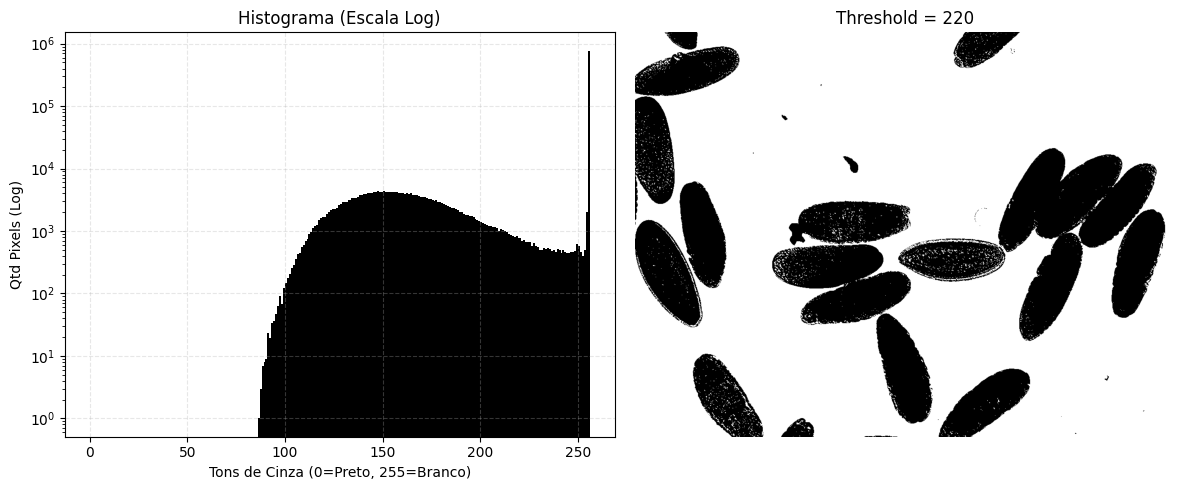

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img1 = cv2.imread("insitu107595.jpg", cv2.IMREAD_GRAYSCALE)

if img1 is None:
    print("Erro na imagem.")
else:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.hist(img1.ravel(), 256, [0, 256], color='black', log=True) 
    plt.title('Histograma (Escala Log)')
    plt.xlabel('Tons de Cinza (0=Preto, 255=Branco)')
    plt.ylabel('Qtd Pixels (Log)')
    plt.grid(True, linestyle='--', alpha=0.3)

    meu_threshold = 220 

    _, img_binaria = cv2.threshold(img1, meu_threshold, 255, cv2.THRESH_BINARY)

    plt.subplot(1, 2, 2)
    plt.imshow(img_binaria, cmap='gray')
    plt.title(f'Threshold = {meu_threshold}')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

2)	Segmentação utilizando a técnica de Threshold Adaptativo (implementar o algortimo). Faça a aplicação do Threshold com e sem suavização prévia

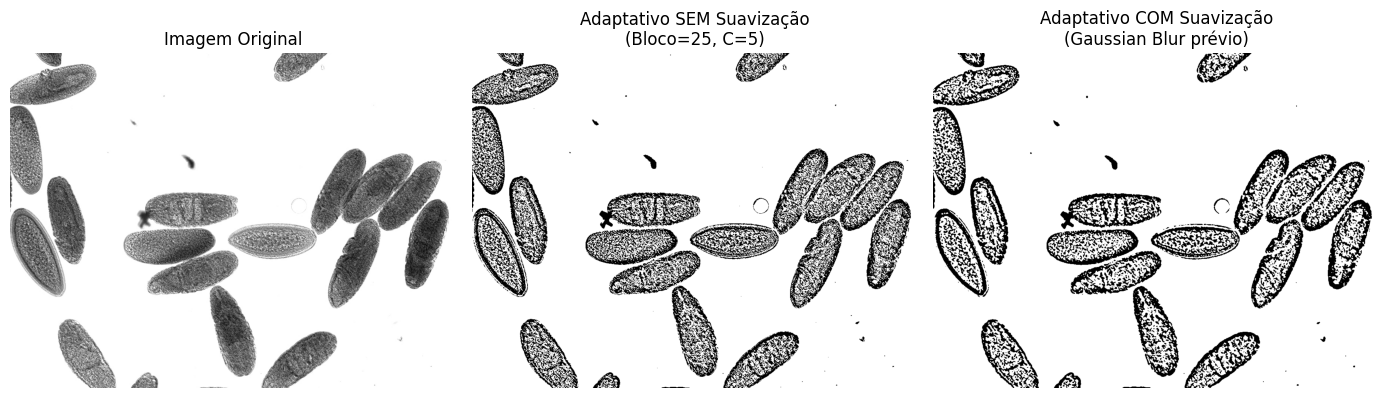

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("insitu107595.jpg", cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Erro: Imagem não encontrada.")
else:
    tamanho_bloco = 25 
    
    C = 5
    
    def threshold_adaptativo_manual(imagem_entrada, bloco, constante):
        media_local = cv2.blur(imagem_entrada, (bloco, bloco))
        limiar = media_local.astype(float) - constante
        
        img_binaria = np.zeros_like(imagem_entrada)
        img_binaria[imagem_entrada > limiar] = 255
        
        return img_binaria
    
    resultado_sem_suavizacao = threshold_adaptativo_manual(img, tamanho_bloco, C)

    img_suavizada = cv2.GaussianBlur(img, (5, 5), 0)
    resultado_com_suavizacao = threshold_adaptativo_manual(img_suavizada, tamanho_bloco, C)

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Imagem Original')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(resultado_sem_suavizacao, cmap='gray')
    plt.title(f'Adaptativo SEM Suavização\n(Bloco={tamanho_bloco}, C={C})')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(resultado_com_suavizacao, cmap='gray')
    plt.title(f'Adaptativo COM Suavização\n(Gaussian Blur prévio)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

3) Segmentação utilizando a técnica de Otsu (implementar) . Faça a aplicação do Threshold com e sem suavização prévia. Mostre um gráfico com o histograma juntamente com a variância entre classes (Exemplo: https://en.wikipedia.org/wiki/File:Otsu%27s_Method_Visualization.gif)

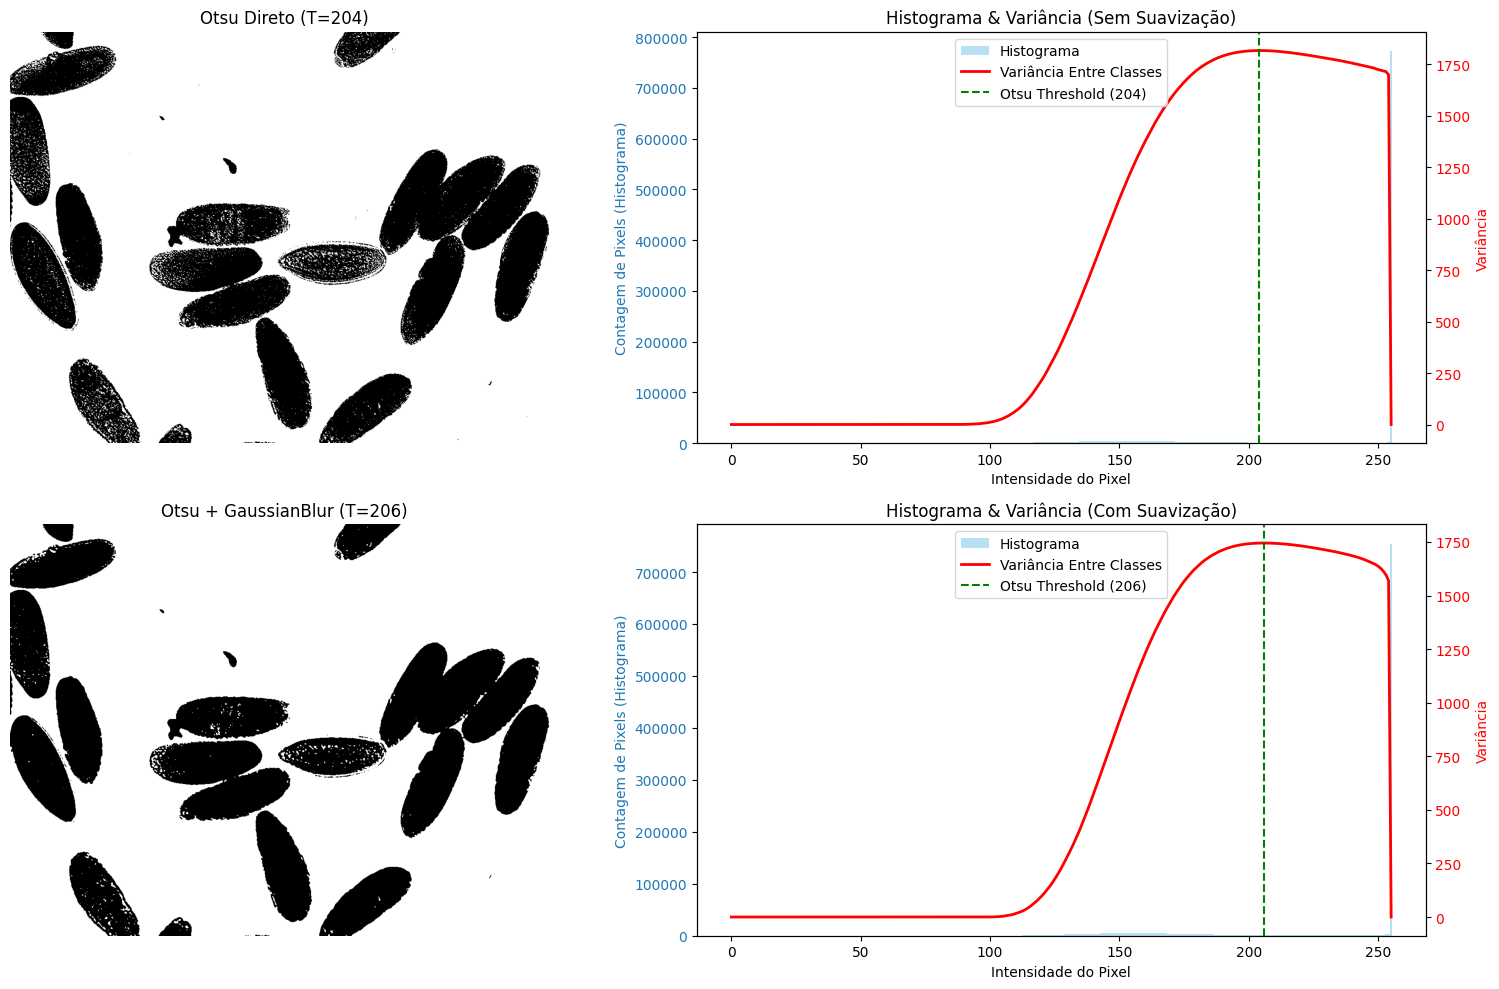

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

nome_arquivo = "insitu107595.jpg"
img = cv2.imread(nome_arquivo, cv2.IMREAD_GRAYSCALE)

if img is None:
    print(f"Erro: Imagem {nome_arquivo} não encontrada.")
else:

    def otsu_manual(imagem):
        hist = cv2.calcHist([imagem], [0], None, [256], [0, 256])
        hist = hist.ravel() 
        
        total_pixels = imagem.size
        hist_norm = hist / total_pixels
        
        variancias_entre_classes = []
        
        bins = np.arange(256)
        
        melhor_thresh = 0
        max_variancia = 0
        
        for t in range(256):
            p1 = hist_norm[:t+1]
            w0 = np.sum(p1)

            p2 = hist_norm[t+1:]
            w1 = np.sum(p2)
            
            if w0 == 0 or w1 == 0:
                variancias_entre_classes.append(0)
                continue
            
            mi0 = np.sum(bins[:t+1] * p1) / w0
            mi1 = np.sum(bins[t+1:] * p2) / w1
            
            variancia = w0 * w1 * ((mi0 - mi1) ** 2)
            variancias_entre_classes.append(variancia)
            
            if variancia > max_variancia:
                max_variancia = variancia
                melhor_thresh = t
                
        _, img_result = cv2.threshold(imagem, melhor_thresh, 255, cv2.THRESH_BINARY)
        
        return melhor_thresh, variancias_entre_classes, img_result, hist


    thresh_raw, var_raw, img_otsu_raw, hist_raw = otsu_manual(img)

    img_blur = cv2.GaussianBlur(img, (5, 5), 0)
    thresh_blur, var_blur, img_otsu_blur, hist_blur = otsu_manual(img_blur)

    def plotar_otsu_wikipedia(ax, histograma, variancias, threshold, titulo):
        ax.bar(np.arange(256), histograma, color='skyblue', width=1, alpha=0.6, label='Histograma')
        ax.set_ylabel('Contagem de Pixels (Histograma)', color='tab:blue')
        ax.tick_params(axis='y', labelcolor='tab:blue')
        ax.set_xlabel('Intensidade do Pixel')
        ax.set_title(titulo)
        
        ax2 = ax.twinx()
        ax2.plot(variancias, color='red', linewidth=2, label='Variância Entre Classes')
        ax2.set_ylabel('Variância', color='red')
        ax2.tick_params(axis='y', labelcolor='red')
        
        ax2.axvline(threshold, color='green', linestyle='--', label=f'Otsu Threshold ({threshold})')
        
        lines, labels = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax2.legend(lines + lines2, labels + labels2, loc='upper center')

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    axes[0, 0].imshow(img_otsu_raw, cmap='gray')
    axes[0, 0].set_title(f'Otsu Direto (T={thresh_raw})')
    axes[0, 0].axis('off')
    
    plotar_otsu_wikipedia(axes[0, 1], hist_raw, var_raw, thresh_raw, 'Histograma & Variância (Sem Suavização)')

    axes[1, 0].imshow(img_otsu_blur, cmap='gray')
    axes[1, 0].set_title(f'Otsu + GaussianBlur (T={thresh_blur})')
    axes[1, 0].axis('off')
    
    plotar_otsu_wikipedia(axes[1, 1], hist_blur, var_blur, thresh_blur, 'Histograma & Variância (Com Suavização)')

    plt.tight_layout()
    plt.show()

In [ ]:
4)	Aplique o Otsu para a imagem HE.jpg, madrill.tiff e  Lenna.jpg (use antes a conversão da imagem para tons de cinza)

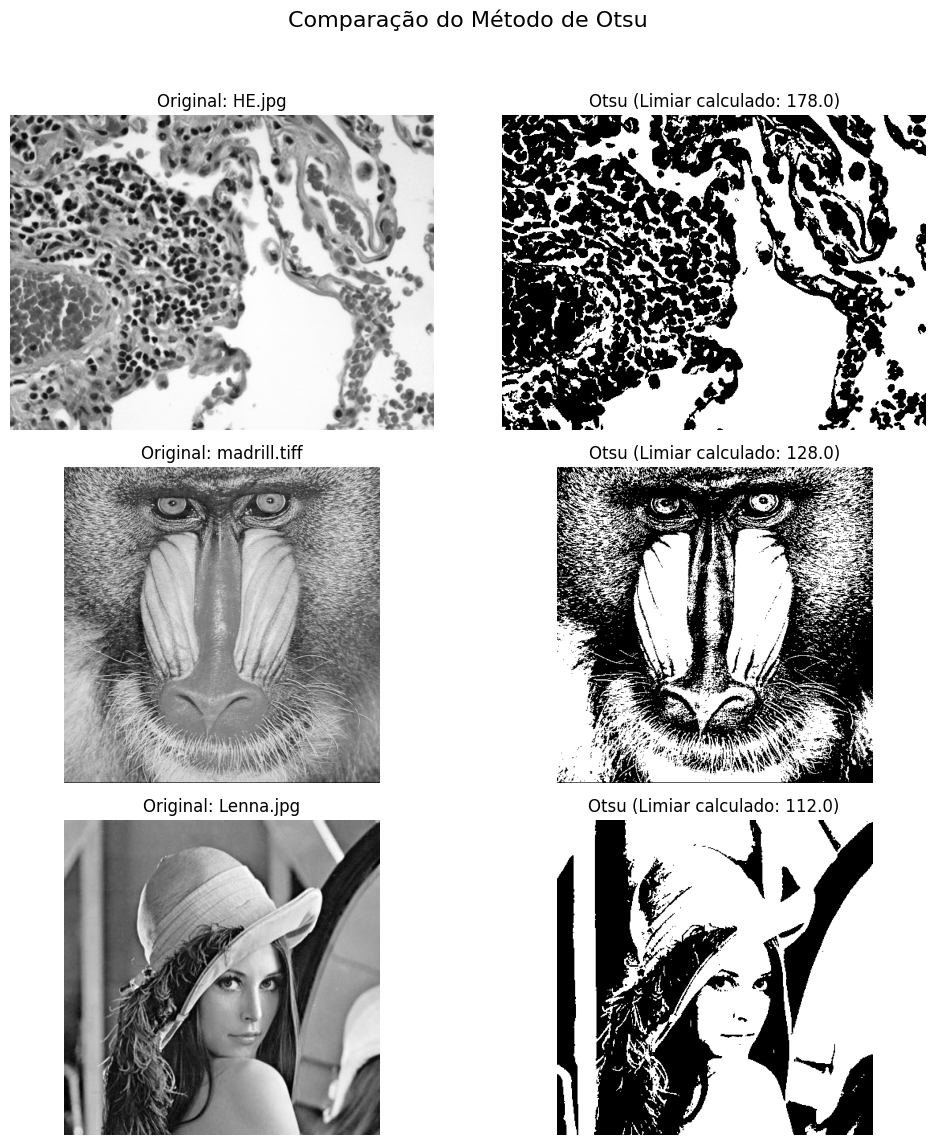

In [8]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

arquivos = ['HE.jpg', 'madrill.tiff', 'Lenna.jpg']

fig, axes = plt.subplots(3, 2, figsize=(10, 12))
fig.suptitle('Comparação do Método de Otsu', fontsize=16)

for i, nome_arquivo in enumerate(arquivos):
    img = cv2.imread(nome_arquivo, cv2.IMREAD_GRAYSCALE)
    
    if img is None:
        print(f"Erro: A imagem '{nome_arquivo}' não foi encontrada.")
        img = np.zeros((100, 100), dtype=np.uint8)
        img_otsu = np.zeros((100, 100), dtype=np.uint8)
        valor_otsu = 0
    else:
        valor_otsu, img_otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
   
    axes[i, 0].imshow(img, cmap='gray')
    axes[i, 0].set_title(f'Original: {nome_arquivo}')
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(img_otsu, cmap='gray')
    axes[i, 1].set_title(f'Otsu (Limiar calculado: {valor_otsu})')
    axes[i, 1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()